# 1. Geospatial Data और GeoPandas क्या है?
जब हमारे डेटा में किसी जगह का Latitude और Longitude, या कोई भौगोलिक सीमा (Polygon/Boundary) दी होती है, तो उसे Geospatial Data कहते हैं।

पाइथन में इस डेटा को पढ़ने और नक्शे पर प्लॉट करने के लिए GeoPandas लाइब्रेरी का इस्तेमाल किया जाता है, जो बिल्कुल आम Pandas की तरह ही काम करती है।

#### Geospatial Data (भौगोलिक डाटा)

### **स्टेप A: लाइब्रेरी इम्पोर्ट करना और शेपफाइल (Shapefile) पढ़ना**

There are many, many different geospatial file formats, such as shapefile, GeoJSON, KML, and GPKG.

shapefile is the most common file type that you'll encounter, and
all of these file types can be quickly loaded with the gpd.read_file() function

In [2]:
import geopandas as gpd

In [11]:

# किसी क्षेत्र की भौगोलिक सीमा (Shapefile) लोड करना
# (Kaggle के एनवायरनमेंट में यह फाइल पहले से मौजूद होती है)
full_data = gpd.read_file('DEC_lands/DEC_lands.shp')

# डेटा के शुरुआती 5 रो देखना
full_data

,OBJECTID,CATEGORY,UNIT,FACILITY,CLASS,UMP,DESCRIPTIO,REGION,COUNTY,URL,SOURCE,UPDATE_,OFFICE,ACRES,LANDS_UID,GREENCERT,SHAPE_AREA,SHAPE_LEN,geometry
0,1,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,NaN,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,738.620192,103,N,2.990365e+06,7927.662385,"POLYGON ((486093.245 4635308.586, 486787.235 4..."
1,2,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,NaN,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,282.553140,1218,N,1.143940e+06,4776.375600,"POLYGON ((491931.514 4637416.256, 491305.424 4..."
2,3,FOR PRES DET PAR,CFP,HANCOCK FP DETACHED PARCEL,WILD FOREST,NaN,DELAWARE COUNTY DETACHED PARCEL,4,DELAWARE,http://www.dec.ny.gov/,DELAWARE RPP,5/12,STAMFORD,234.291262,1780,N,9.485476e+05,5783.070364,"POLYGON ((486000.287 4635834.453, 485007.55 46..."
3,4,FOR PRES DET PAR,CFP,GREENE COUNTY FP DETACHED PARCEL,WILD FOREST,NaN,NaN,4,GREENE,http://www.dec.ny.gov/,GREENE RPP,5/12,STAMFORD,450.106464,2060,N,1.822293e+06,7021.644833,"POLYGON ((541716.775 4675243.268, 541217.58 46..."
4,6,FOREST PRESERVE,AFP,SARANAC LAKES WILD FOREST,WILD FOREST,SARANAC LAKES,NaN,5,ESSEX,http://www.dec.ny.gov/lands/22593.html,"DECRP, ESSEX RPP",12/96,RAY BROOK,69.702387,1517,N,2.821959e+05,2663.909932,"POLYGON ((583896.043 4909643.187, 583891.2 490..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2978,8976,UNCLASSIFIED,NaN,NaN,NaN,NaN,NaN,6,ST. LAWRENCE,https://www.dec.ny.gov/index.html,DECRP,12/17,POTSDAM,19.122040,4703,N,7.741717e+04,3217.461334,"POLYGON ((476797.577 4963760.373, 476813.252 4..."
2979,9281,UNCLASSIFIED,NaN,NaN,NaN,NaN,NaN,6,ST. LAWRENCE,https://www.dec.ny.gov/index.html,DECRP,12/17,POTSDAM,1.764896,4704,N,7.145329e+03,452.953460,"POLYGON ((474212.474 4961236.101, 474189.987 4..."
2980,9282,UNIQUE AREA,SENECA 90,JUNIUS POND UNIQUE AREA,NaN,BARE HILL,MANAGED BY DFW,8,SENECA,http://www.dec.ny.gov/,DECRP,12/17,AVON,95.815236,4708,N,3.879159e+05,2619.450307,"POLYGON ((340844.385 4757499.092, 341048.855 4..."
2981,9288,UNIQUE AREA,NaN,VROMAN'S NOSE UNIQUE AREA,NaN,NaN,NaN,4,SCHOHARIE,https://www.dec.ny.gov/index.html,DECRP,12/17,STAMFORD,138.487592,4706,NaN,5.606785e+05,4361.619502,"POLYGON ((553048.551 4715991.593, 553061.611 4..."


In [8]:
type(full_data)

geopandas.geodataframe.GeoDataFrame

In [9]:
data = full_data.loc[:, ["CLASS", "COUNTY", "geometry"]].copy()


In [10]:
# How many lands of each type are there?
data.CLASS.value_counts()

CLASS
WILD FOREST                   965
INTENSIVE USE                 108
PRIMITIVE                      60
WILDERNESS                     52
ADMINISTRATIVE                 17
UNCLASSIFIED                    7
HISTORIC                        5
PRIMITIVE BICYCLE CORRIDOR      4
CANOE AREA                      1
Name: count, dtype: int64

In [13]:
wild_lands = data.loc[data.CLASS.isin(['WILD FOREST', 'WILDERNESS'])].copy()
wild_lands

,CLASS,COUNTY,geometry
0,WILD FOREST,DELAWARE,"POLYGON ((486093.245 4635308.586, 486787.235 4..."
1,WILD FOREST,DELAWARE,"POLYGON ((491931.514 4637416.256, 491305.424 4..."
2,WILD FOREST,DELAWARE,"POLYGON ((486000.287 4635834.453, 485007.55 46..."
3,WILD FOREST,GREENE,"POLYGON ((541716.775 4675243.268, 541217.58 46..."
4,WILD FOREST,ESSEX,"POLYGON ((583896.043 4909643.187, 583891.2 490..."
...,...,...,...
2969,WILD FOREST,HERKIMER,"POLYGON ((506537.533 4791279.174, 506253.858 4..."
2971,WILDERNESS,HERKIMER,"POLYGON ((494287.078 4879426.659, 494303.068 4..."
2972,WILD FOREST,ONEIDA,"POLYGON ((488163.843 4823797.5, 488164.857 482..."
2973,WILD FOREST,HERKIMER,"POLYGON ((499824.232 4801687.62, 500127.226 48..."


<Axes: >

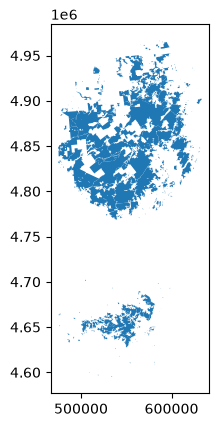

In [14]:
wild_lands.plot()

In [15]:
# View the first five entries in the "geometry" column
wild_lands.geometry.head()

0    POLYGON ((486093.245 4635308.586, 486787.235 4...
1    POLYGON ((491931.514 4637416.256, 491305.424 4...
2    POLYGON ((486000.287 4635834.453, 485007.55 46...
3    POLYGON ((541716.775 4675243.268, 541217.58 46...
4    POLYGON ((583896.043 4909643.187, 583891.2 490...
Name: geometry, dtype: geometry

In [37]:
POI_data = gpd.read_file("DEC_pointsinterest/Decptsofinterest.shp")

# Foot trails in New York state (LineString)
roads_trails = gpd.read_file("DEC_roadstrails/Decroadstrails.shp")
# देखें कि कॉलम के असली नाम क्या हैं
print(POI_data.ASSET)
print(roads_trails.ASSET)

0        PRIMITIVE CAMPSITE
1        PRIMITIVE CAMPSITE
2        PRIMITIVE CAMPSITE
3       UNPAVED PARKING LOT
4           PICNIC PAVILION
               ...         
4312     PRIMITIVE CAMPSITE
4313    UNPAVED PARKING LOT
4314     PRIMITIVE CAMPSITE
4315                LEAN-TO
4316     PRIMITIVE CAMPSITE
Name: ASSET, Length: 4317, dtype: str
0       SNOWMOBILE TRAIL
1       SNOWMOBILE TRAIL
2       SNOWMOBILE TRAIL
3       SNOWMOBILE TRAIL
4       SNOWMOBILE TRAIL
              ...       
8137        UNPAVED ROAD
8138    SNOWMOBILE TRAIL
8139        UNPAVED ROAD
8140        UNPAVED ROAD
8141          FOOT TRAIL
Name: ASSET, Length: 8142, dtype: str


In [38]:
# Campsites in New York state (Point)
POI_data = gpd.read_file("DEC_pointsinterest/Decptsofinterest.shp")
campsites = POI_data.loc[POI_data.ASSET=='PRIMITIVE CAMPSITE'].copy()

# Foot trails in New York state (LineString)
roads_trails = gpd.read_file("DEC_roadstrails/Decroadstrails.shp")
trails = roads_trails.loc[roads_trails.ASSET=='FOOT TRAIL'].copy()

# County boundaries in New York state (Polygon)
counties = gpd.read_file("NY_county_boundaries/NY_county_boundaries.shp")

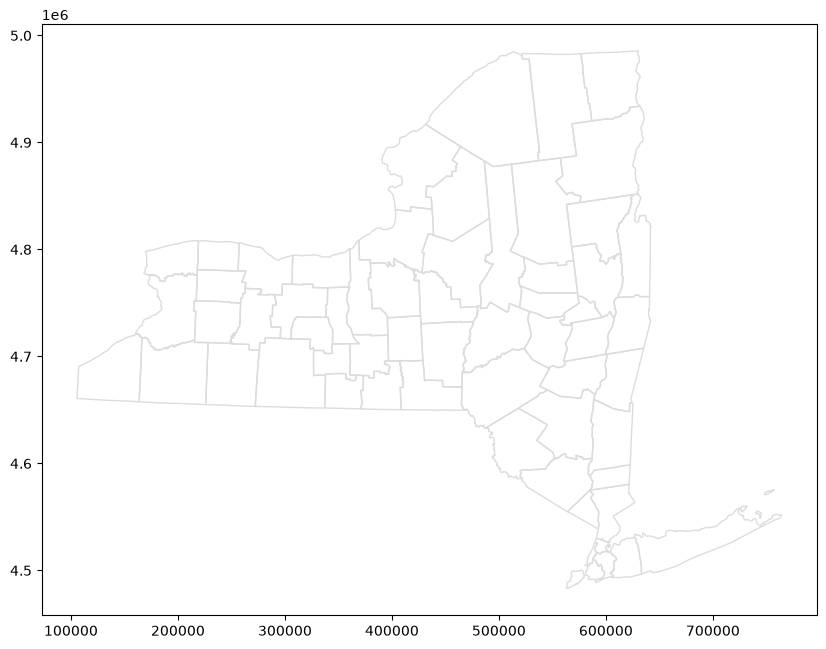

In [41]:
# Define a base map with county boundaries
ax = counties.plot(figsize=(10,10), color='none', edgecolor='gainsboro', zorder=3)



<Axes: >

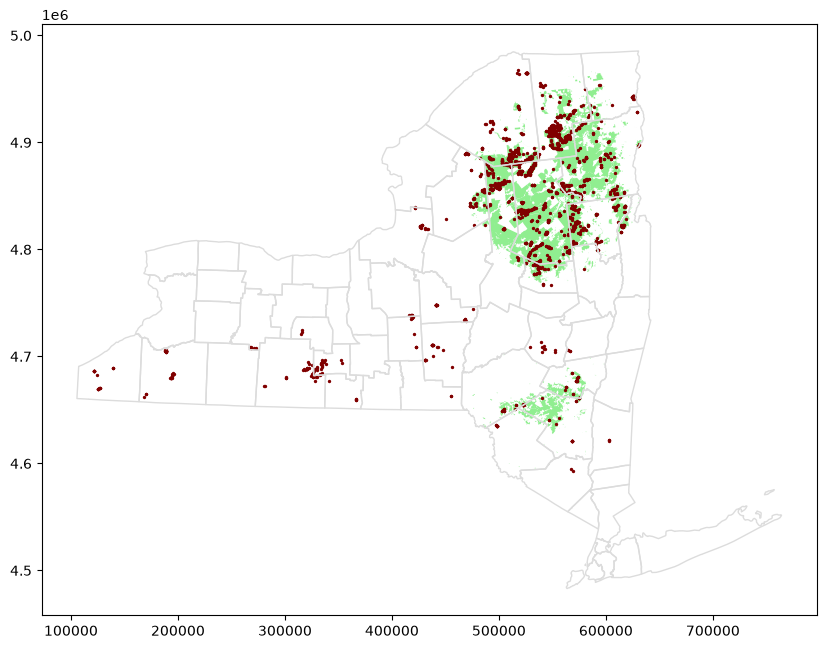

In [43]:
# Define a base map with county boundaries
ax = counties.plot(figsize=(10,10), color='none', edgecolor='gainsboro', zorder=3)
# Add wild lands, campsites, and foot trails to the base map
wild_lands.plot(color='lightgreen', ax=ax)
campsites.plot(color='maroon', markersize=2, ax=ax)
#trails.plot(color='black', markersize=1, ax=ax)

# Coordinate reference system (CRS) 
to show how the projected points correspond to real locations on Earth.

In [75]:
# Load a GeoDataFrame containing regions in Ghana
regions = gpd.read_file("ghana/ghana/Regions/Map_of_Regions_in_Ghana.shp")
print(regions.crs)    # EPSG:32630
regions   # regions of ghana

EPSG:32630


,Region,geometry
0,Ashanti,"POLYGON ((686446.075 842986.894, 686666.193 84..."
1,Brong Ahafo,"POLYGON ((549970.457 968447.094, 550073.003 96..."
2,Central,"POLYGON ((603176.584 695877.238, 603248.424 69..."
3,Eastern,"POLYGON ((807307.254 797910.553, 807311.908 79..."
4,Greater Accra,"POLYGON ((858081.638 676424.913, 858113.115 67..."
5,Northern,"POLYGON ((818287.468 1185632.455, 818268.664 1..."
6,Upper East,"POLYGON ((811994.328 1230449.528, 812004.699 1..."
7,Upper West,"POLYGON ((658854.315 1220818.656, 659057.21 12..."
8,Volta,"POLYGON ((899718.788 875120.098, 899564.444 87..."
9,Western,"POLYGON ((490349.315 771271.143, 490530.091 77..."


And, you can get the length of a LineString from the length attribute.

Or, you can get the area of a Polygon from the area attribute.

In [74]:
# Calculate the area (in square meters) of each polygon in the GeoDataFrame 
regions.loc[:, "AREA"] = regions.geometry.area / 10**6                          # adding area column

print("Area of Ghana: {} square kilometers".format(regions.AREA.sum()))
print("CRS:", regions.crs)
regions.head()

Area of Ghana: 239584.5760055668 square kilometers
CRS: EPSG:32630


,Region,geometry,AREA
0,Ashanti,"POLYGON ((686446.075 842986.894, 686666.193 84...",24379.017777
1,Brong Ahafo,"POLYGON ((549970.457 968447.094, 550073.003 96...",40098.168231
2,Central,"POLYGON ((603176.584 695877.238, 603248.424 69...",9665.626760
3,Eastern,"POLYGON ((807307.254 797910.553, 807311.908 79...",18987.625847
4,Greater Accra,"POLYGON ((858081.638 676424.913, 858113.115 67...",3706.511145


In [52]:
import pandas as pd 
# Create a DataFrame with health facilities in Ghana
facilities_df = pd.read_csv("ghana/ghana/health_facilities.csv")
facilities_df

,Region,District,FacilityName,Type,Town,Ownership,Latitude,Longitude
0,Ashanti,Offinso North,A.M.E Zion Clinic,Clinic,Afrancho,CHAG,7.40801,-1.96317
1,Ashanti,Bekwai Municipal,Abenkyiman Clinic,Clinic,Anwiankwanta,Private,6.46312,-1.58592
2,Ashanti,Adansi North,Aboabo Health Centre,Health Centre,Aboabo No 2,Government,6.22393,-1.34982
3,Ashanti,Afigya-Kwabre,Aboabogya Health Centre,Health Centre,Aboabogya,Government,6.84177,-1.61098
4,Ashanti,Kwabre,Aboaso Health Centre,Health Centre,Aboaso,Government,6.84177,-1.61098
...,...,...,...,...,...,...,...,...
3751,Western,Sefwi-Akontombra,Ackaakrom CHPS,CHPS,Ackaakrom,Government,NaN,NaN
3752,Western,Sefwi-Akontombra,Apprutu CHPS,CHPS,Apprutu,Government,NaN,NaN
3753,Western,Sefwi-Akontombra,Kojokrom CHPS,CHPS,Kojokrom,Government,NaN,NaN
3754,Western,Sefwi-Akontombra,Yawkrom CHPS,CHPS,Yawkrom,Government,NaN,NaN


In [57]:
# Convert the DataFrame to a GeoDataFrame (will have new geometry column )
facilities = gpd.GeoDataFrame(facilities_df, geometry=gpd.points_from_xy(facilities_df.Longitude, facilities_df.Latitude))

# Set the coordinate reference system (CRS) to EPSG 4326
facilities.crs = {'init': 'epsg:4326'}

# View the first five rows of the GeoDataFrame
facilities.head()

E:\anaconda\Lib\site-packages\pyproj\crs\crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)


,Region,District,FacilityName,Type,Town,Ownership,Latitude,Longitude,geometry
0,Ashanti,Offinso North,A.M.E Zion Clinic,Clinic,Afrancho,CHAG,7.40801,-1.96317,POINT (-1.96317 7.40801)
1,Ashanti,Bekwai Municipal,Abenkyiman Clinic,Clinic,Anwiankwanta,Private,6.46312,-1.58592,POINT (-1.58592 6.46312)
2,Ashanti,Adansi North,Aboabo Health Centre,Health Centre,Aboabo No 2,Government,6.22393,-1.34982,POINT (-1.34982 6.22393)
3,Ashanti,Afigya-Kwabre,Aboabogya Health Centre,Health Centre,Aboabogya,Government,6.84177,-1.61098,POINT (-1.61098 6.84177)
4,Ashanti,Kwabre,Aboaso Health Centre,Health Centre,Aboaso,Government,6.84177,-1.61098,POINT (-1.61098 6.84177)


<Axes: >

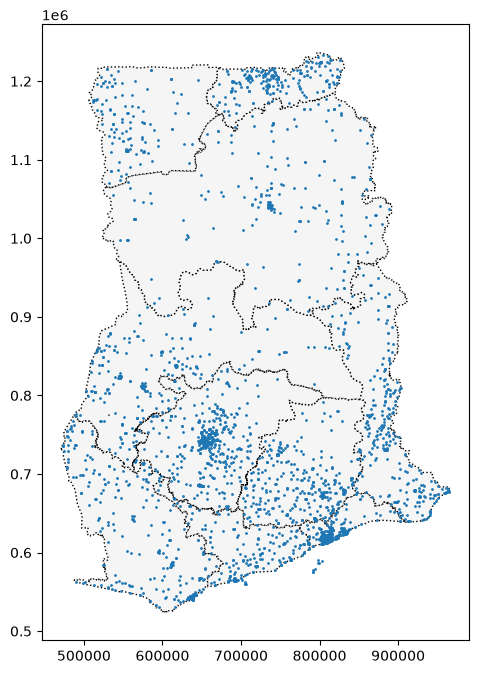

In [54]:
# Create a map
ax = regions.plot(figsize=(8,8), color='whitesmoke', linestyle=':', edgecolor='black')
facilities.to_crs(epsg=32630).plot(markersize=1, ax=ax)

The to_crs() method modifies only the "geometry" column: all other columns are left as-is.

In [55]:
# The "Latitude" and "Longitude" columns are unchanged
facilities.to_crs(epsg=32630).head()

,Region,District,FacilityName,Type,Town,Ownership,Latitude,Longitude,geometry
0,Ashanti,Offinso North,A.M.E Zion Clinic,Clinic,Afrancho,CHAG,7.40801,-1.96317,POINT (614422.662 818986.851)
1,Ashanti,Bekwai Municipal,Abenkyiman Clinic,Clinic,Anwiankwanta,Private,6.46312,-1.58592,POINT (656373.863 714616.547)
2,Ashanti,Adansi North,Aboabo Health Centre,Health Centre,Aboabo No 2,Government,6.22393,-1.34982,POINT (682573.395 688243.477)
3,Ashanti,Afigya-Kwabre,Aboabogya Health Centre,Health Centre,Aboabogya,Government,6.84177,-1.61098,POINT (653484.49 756478.812)
4,Ashanti,Kwabre,Aboaso Health Centre,Health Centre,Aboaso,Government,6.84177,-1.61098,POINT (653484.49 756478.812)


In [77]:
# Get the x-coordinate of each point
facilities.geometry.x.head()               #that's Logitude

0   -1.96317
1   -1.58592
2   -1.34982
3   -1.61098
4   -1.61098
dtype: float64

# Interactive Maps

Learn how to make interactive heatmaps, choropleth maps

In [ ]:
!pip install folium

In [80]:
import pandas as pd
import geopandas as gpd
import math
import folium
from folium import Choropleth, Circle, Marker
from folium.plugins import HeatMap, MarkerCluster

In [81]:
# Create a map
m_1 = folium.Map(location=[42.32,-71.0589], tiles='openstreetmap', zoom_start=10)

# Display the map
m_1

In [82]:
# Load the data
crimes = pd.read_csv("crimes-in-boston/crimes-in-boston/crime.csv", encoding='latin-1')

# Drop rows with missing locations
crimes.dropna(subset=['Lat', 'Long', 'DISTRICT'], inplace=True)

# Focus on major crimes in 2018
crimes = crimes[crimes.OFFENSE_CODE_GROUP.isin([
    'Larceny', 'Auto Theft', 'Robbery', 'Larceny From Motor Vehicle', 'Residential Burglary',
    'Simple Assault', 'Harassment', 'Ballistics', 'Aggravated Assault', 'Other Burglary', 
    'Arson', 'Commercial Burglary', 'HOME INVASION', 'Homicide', 'Criminal Harassment', 
    'Manslaughter'])]
crimes = crimes[crimes.YEAR>=2018]

# Print the first five rows of the table
crimes.head()

,INCIDENT_NUMBER,OFFENSE_CODE,OFFENSE_CODE_GROUP,OFFENSE_DESCRIPTION,DISTRICT,REPORTING_AREA,SHOOTING,OCCURRED_ON_DATE,YEAR,MONTH,DAY_OF_WEEK,HOUR,UCR_PART,STREET,Lat,Long,Location
0,I182070945,619,Larceny,LARCENY ALL OTHERS,D14,808,NaN,2018-09-02 13:00:00,2018,9,Sunday,13,Part One,LINCOLN ST,42.357791,-71.139371,"(42.35779134, -71.13937053)"
6,I182070933,724,Auto Theft,AUTO THEFT,B2,330,NaN,2018-09-03 21:25:00,2018,9,Monday,21,Part One,NORMANDY ST,42.306072,-71.082733,"(42.30607218, -71.08273260)"
8,I182070931,301,Robbery,ROBBERY - STREET,C6,177,NaN,2018-09-03 20:48:00,2018,9,Monday,20,Part One,MASSACHUSETTS AVE,42.331521,-71.070853,"(42.33152148, -71.07085307)"
19,I182070915,614,Larceny From Motor Vehicle,LARCENY THEFT FROM MV - NON-ACCESSORY,B2,181,NaN,2018-09-02 18:00:00,2018,9,Sunday,18,Part One,SHIRLEY ST,42.325695,-71.068168,"(42.32569490, -71.06816778)"
24,I182070908,522,Residential Burglary,BURGLARY - RESIDENTIAL - NO FORCE,B2,911,NaN,2018-09-03 18:38:00,2018,9,Monday,18,Part One,ANNUNCIATION RD,42.335062,-71.093168,"(42.33506218, -71.09316781)"


#### Plotting points

Daytime robberies.

In [85]:
daytime_robberies = crimes[((crimes.OFFENSE_CODE_GROUP == 'Robbery') & \
                         (crimes.HOUR.isin(range(9,18))))]

#### folium.Marker

We add markers to the map with folium.Marker(). Each marker below corresponds to a different robbery.


In [89]:

# Create a map
m_2 = folium.Map(location=[42.32,-71.0589], tiles='cartodbpositron', zoom_start=13)

# Add points to the map
for idx, row in daytime_robberies.iterrows():
    Marker([row['Lat'], row['Long']]).add_to(m_2)

# Display the map
m_2

folium.plugins.MarkerCluster
If we have a lot of markers to add, folium.plugins.MarkerCluster() can help to declutter the map. Each marker is added to a MarkerCluster object.


In [88]:

# Create the map
m_3 = folium.Map(location=[42.32,-71.0589], tiles='cartodbpositron', zoom_start=13)

# Add points to the map
mc = MarkerCluster()
for idx, row in daytime_robberies.iterrows():
    if not math.isnan(row['Long']) and not math.isnan(row['Lat']):
        mc.add_child(Marker([row['Lat'], row['Long']]))
m_3.add_child(mc)

# Display the map
m_3

# Bubble maps
A bubble map uses circles instead of markers. By varying the size and color of each circle, we can also show the relationship between location and two other variables.

We create a bubble map by using folium.Circle() to iteratively add circles. In the code cell below, robberies that occurred in hours 9-12 are plotted in green, whereas robberies from hours 13-17 are plotted in red.

In [90]:
# Create a base map
m_4 = folium.Map(location=[42.32,-71.0589], tiles='cartodbpositron', zoom_start=13)

def color_producer(val):
    if val <= 12:
        return 'forestgreen'     # robberies that occurred in hours 9-12 are plotted in green
    else:
        return 'darkred'         # robberies from hours 13-17 are plotted in red.

# Add a bubble map to the base map
for i in range(0,len(daytime_robberies)):
    Circle(
        location=[daytime_robberies.iloc[i]['Lat'], daytime_robberies.iloc[i]['Long']],
        radius=20,
        color=color_producer(daytime_robberies.iloc[i]['HOUR'])).add_to(m_4)

# Display the map
m_4

# Heatmaps

To create a heatmap, we use folium.plugins.HeatMap(). This shows the density of crime in different areas of the city, where red areas have relatively more criminal incidents.

As we'd expect for a big city, most of the crime happens near the center.

In [91]:
# Create a base map
m_5 = folium.Map(location=[42.32,-71.0589], tiles='cartodbpositron', zoom_start=12)

# Add a heatmap to the base map
HeatMap(data=crimes[['Lat', 'Long']], radius=10).add_to(m_5)

# Display the map
m_5

# Choropleth maps¶

To understand how crime varies by police district, we'll create a choropleth map.

As a first step, we create a GeoDataFrame where each district is assigned a different row, and the "geometry" column contains the geographical boundaries.

In [ ]:
# GeoDataFrame with geographical boundaries of Boston police districts
districts_full = gpd.read_file('Police_Districts/Police_Districts.shp')
districts = districts_full[["DISTRICT", "geometry"]].set_index("DISTRICT")
districts.head()

We also create a Pandas Series called plot_dict that shows the number of crimes in each district.


In [ ]:
# Number of crimes in each police district
plot_dict = crimes.DISTRICT.value_counts()
plot_dict.head()

Using the folium.Choropleth() class, we can create a choropleth map. If the map below does not render for you, try viewing the page in a different web browser.


In [ ]:
import folium
from folium import Choropleth

# Create a base map
m_6 = folium.Map(
    location=[42.32, -71.0589], tiles='cartodbpositron', zoom_start=12
)

# Add a choropleth map to the base map
Choropleth(
    geo_data=districts.__geo_interface__,
    data=plot_dict,
    key_on='feature.id',
    fill_color='YlGnBu',
    legend_name='Major criminal incidents (Jan-Aug 2018)',  # यहाँ '/' हटाकर सही कर दिया गया है
).add_to(m_6)

# Display the map
m_6

Note that folium.Choropleth() takes several arguments:

geo_data is a GeoJSON FeatureCollection containing the boundaries of each geographical area.
    
**In the code above**, we **convert the districts GeoDataFrame** to a **GeoJSON FeatureCollection with the __geo_interface__** attribute.
    
data is a Pandas Series containing the values that will be used to color-code each geographical area.
    
key_on will always be set to feature.id.
    
This refers to the fact that the GeoDataFrame used for geo_data and the Pandas Series provided in data have the same index. 

To understand the details, we'd have to look more closely at the structure of a GeoJSON Feature Collection 
(where the value corresponding to the "features" key is a list, wherein each entry is a dictionary containing an "id" key).

fill_color sets the color scale.
    
legend_name labels the legend in the top right corner of the map.

# Geocoding¶
Geocoding is the process of converting the name of a place or an address to a location on a map

We'll use geopy to do all of our geocoding.

In [249]:
!pip install geopy

In [250]:
from geopy.geocoders import Nominatim

In [251]:
geolocator = Nominatim(user_agent="kaggle_learn")
location = geolocator.geocode("Pyramid of Khufu")

In [252]:
point = location.point
print("Latitude:", point.latitude)
print("Longitude:", point.longitude)
print(location.point)

Latitude: 29.9791647
Longitude: 31.1342133
29 58m 44.9929s N, 31 8m 3.16788s E


In [253]:
universities = pd.read_csv("top_universities.csv")
universities.head()

,Name
0,University of Oxford
1,University of Cambridge
2,Imperial College London
3,ETH Zurich
4,UCL


Then we can use a lambda function to apply the geocoder to every row in the DataFrame.

(We use a try/except statement to account for the case that the geocoding is unsuccessful.)

In [ ]:
def my_geocoder(row):
    try:
        point = geolocator.geocode(row).point
        return pd.Series({'Latitude': point.latitude, 'Longitude': point.longitude})
    except:
        return None

universities[['Latitude', 'Longitude']] = universities.apply(lambda x: my_geocoder(x['Name']), axis=1)

print("{}% of addresses were geocoded!".format(
    (1 - sum(np.isnan(universities["Latitude"])) / len(universities)) * 100))

# Drop universities that were not successfully geocoded
universities = universities.loc[~np.isnan(universities["Latitude"])]
universities = gpd.GeoDataFrame(
    universities, geometry=gpd.points_from_xy(universities.Longitude, universities.Latitude))
universities.crs = {'init': 'epsg:4326'}
universities.head()

In [ ]:
# Create a map
m = folium.Map(location=[54, 15], tiles='openstreetmap', zoom_start=2)

# Add points to the map
for idx, row in universities.iterrows():
    Marker([row['Latitude'], row['Longitude']], popup=row['Name']).add_to(m)

# Display the map
m

<hr style="border: none; height: 3px; background: linear-gradient(to right, #4facfe, #00f2fe); border-radius: 2px; margin: 30px 0;">

# Table joins

Now, we'll switch topics and think about how to combine data from different sources.

# Attribute join
You already know how to use pd.DataFrame.join() to combine information from multiple DataFrames with a shared index. We refer to this way of joining data (by simpling matching values in the index) as an attribute join.

When performing an attribute join with a GeoDataFrame, it's best to use the gpd.GeoDataFrame.merge(). To illustrate this, we'll work with a GeoDataFrame europe_boundaries containing the boundaries for every country in Europe.

In [141]:
import geopandas as gpd
import pandas as pd

# ==========================================
# 1. ATTRIBUTE JOIN (अलग से डाउनलोड की गई फाइलों के साथ)
# ==========================================

# डाउनलोड की गई GeoJSON फाइल को लोड करना
world_map = gpd.read_file('countries.geojson')
world_map.columns

Index(['featurecla', 'scalerank', 'LABELRANK', 'SOVEREIGNT', 'SOV_A3',
       'ADM0_DIF', 'LEVEL', 'TYPE', 'TLC', 'ADMIN',
       ...
       'FCLASS_TR', 'FCLASS_ID', 'FCLASS_PL', 'FCLASS_GR', 'FCLASS_IT',
       'FCLASS_NL', 'FCLASS_SE', 'FCLASS_BD', 'FCLASS_UA', 'geometry'],
      dtype='str', length=169)

In [142]:
world_map.NAME

0                          Fiji
1                      Tanzania
2                     W. Sahara
3                        Canada
4      United States of America
                 ...           
172                      Serbia
173                  Montenegro
174                      Kosovo
175         Trinidad and Tobago
176                    S. Sudan
Name: NAME, Length: 177, dtype: str

In [136]:
# डाउनलोड की गई CSV फाइल को लोड करना (जिसमें अतिरिक्त डेटा जैसे GDP या Population हो)
extra_data = pd.read_csv('countries_data.csv')
extra_data

,NAME,Happiness_Score,Region
0,India,6.5,Asia
1,United States of America,7.2,North America
2,Brazil,6.8,South America
3,Germany,7.5,Europe
4,Australia,7.4,Oceania


In [133]:
# दोनों फाइलों में एक कॉमन कॉलम होता है (जैसे 'NAME' य)
# मान लीजिए कॉमन कॉलम का नाम 'NAME' है, तो हम दोनों को आपस में मर्ज करते हैं:
attribute_joined = world_map.merge(extra_data, on='NAME', how='inner')

print('--- Attribute Join का रिजल्ट ---')
print(attribute_joined[['NAME', 'POP_EST', 'geometry']].head())

--- Attribute Join का रिजल्ट ---
                       NAME       POP_EST  \
0  United States of America  3.282395e+08   
1                    Brazil  2.110495e+08   
2                     India  1.366418e+09   
3                   Germany  8.313280e+07   
4                 Australia  2.536431e+07   

                                            geometry  
0  MULTIPOLYGON (((-122.84 49, -120 49, -117.0312...  
1  POLYGON ((-53.37366 -33.76838, -53.65054 -33.2...  
2  POLYGON ((97.32711 28.26158, 97.40256 27.88254...  
3  POLYGON ((14.11969 53.75703, 14.35332 53.24817...  
4  MULTIPOLYGON (((147.68926 -40.80826, 148.28907...  


**रिजल्ट**: inner जॉइन सिर्फ उन्हीं देशों को रखेगा जो दोनों जगह (नक्शे में भी और CSV में भी) मौजूद हैं। बाकी के सारे देश हट जाएंगे और हमें सिर्फ उन 5 देशों का नक्शा और उनका डेटा मिल जाएगा।

In [143]:
from shapely.geometry import Point
import geopandas as gpd
import pandas as pd

# 1. देशों का नक्शा लोड करना (जिसमें पॉलीगॉन/सीमाएं हैं)
world_map = gpd.read_file('countries.geojson')

# 2. शहरों की CSV फाइल लोड करना (जिसमें Latitude और Longitude हैं)
cities_df = pd.read_csv('cities.csv')

In [147]:
# 3. Pandas DataFrame को GeoDataFrame में बदलना (पॉइंट्स बनाना)
# ध्यान दें: x = Longitude, y = Latitude
geometry = [
    Point(xy) for xy in zip(cities_df['Longitude'], cities_df['Latitude'])
]
cities_gdf = gpd.GeoDataFrame(cities_df, geometry=geometry, crs='EPSG:4326')

# 4. SPATIAL JOIN करना (gpd.sjoin का उपयोग)
# यह अपने आप चेक करेगा कि कौन सा शहर किस देश के पॉलीगॉन (सीमा) के अंदर आता है
spatial_joined = gpd.sjoin( cities_gdf, world_map, how='inner', predicate='within')

print('--- Spatial Join का रिजल्ट ---\n')
# अब यह बता देगा कि New Delhi किस देश (NAME) के अंदर है!
print(spatial_joined[['City_Name', 'NAME', 'geometry']])

--- Spatial Join का रिजल्ट ---

         City_Name                      NAME                   geometry
0        New Delhi                     India     POINT (77.209 28.6139)
1  Washington D.C.  United States of America   POINT (-77.0369 38.9072)
2         Brasilia                    Brazil  POINT (-47.9292 -15.7801)
3           Berlin                   Germany       POINT (13.405 52.52)
4         Canberra                 Australia    POINT (149.13 -35.2809)


<hr style="border: none; height: 3px; background: linear-gradient(to right, #4facfe, #00f2fe); border-radius: 2px; margin: 30px 0;">

# Proximity Analysis

**Proximity Analysis** ट्यूटोरियल में हम यह सीखते हैं कि दो जियोस्पेशियल पॉइंट्स के बीच की दूरी (Distance) कैसे मापी जाती है

दो पॉइंट्स के बीच की **दूरी (Distance)** कैसे निकालते हैं।  

किसी पॉइंट के चारों तरफ **बफर (Buffer - दायरा)** कैसे बनाते हैं।

In [228]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

## Calculating distance from one geometry to other **(In same geojson data)**

In [205]:
import geopandas as gpd

# 1. नेचुरल अर्थ का असली एयरपोर्ट्स (पॉइंट्स) वाला डेटा लोड करें
# यह सीधे ऑनलाइन लिंक से पॉइंट्स लोड कर लेगा
url_airports = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_airports.geojson'
stations = gpd.read_file(url_airports)

# 2. अब चेक करें कि क्या यह पॉइंट्स हैं या नहीं
print('(Geometry Type):', stations.geom_type.unique())
print('\nFirst 5 Stations are:\n\n', stations[[ 'name','geometry']].head())

# 3. अब दूरी मापने वाला कोड बिल्कुल सही काम करेगा:
stations_proj = stations.to_crs(epsg=3857)  # दूरी मीटर में मापने के लिए CRS बदलना
stations_proj.head(3)

(Geometry Type): <ArrowStringArray>
['Point']
Length: 1, dtype: str

First 5 Stations are:

           name                   geometry
0     Sahnewal  POINT (75.95707 30.85036)
1      Solapur  POINT (75.93306 17.62542)
2  Birsa Munda   POINT (85.3236 23.31772)
3        Ahwaz  POINT (48.74711 31.34316)
4      Gwalior  POINT (78.21722 26.28549)


,scalerank,featurecla,type,name,abbrev,location,gps_code,iata_code,wikipedia,natlscale,...,name_vi,name_zh,wdid_score,ne_id,name_fa,name_he,name_uk,name_ur,name_zht,geometry
0,9,Airport,small,Sahnewal,LUH,terminal,VILD,LUH,http://en.wikipedia.org/wiki/Sahnewal_Airport,8,...,NaN,NaN,4.0,1159113785,فرودگاه سهنول,NaN,NaN,NaN,NaN,POINT (8455502.577 3613330.751)
1,9,Airport,mid,Solapur,SSE,terminal,VASL,SSE,http://en.wikipedia.org/wiki/Solapur_Airport,8,...,NaN,NaN,4.0,1159113803,فرودگاه سولاپور,NaN,NaN,NaN,NaN,POINT (8452829.574 1993750.221)
2,9,Airport,mid,Birsa Munda,IXR,terminal,VERC,IXR,http://en.wikipedia.org/wiki/Birsa_Munda_Airport,8,...,Sân bay Birsa Munda,比尔萨·蒙达机场,4.0,1159113831,فرودگاه بیرسا موندا,NaN,NaN,NaN,比爾薩·蒙達機場,POINT (9498179.371 2670487.592)


In [224]:
first_station = stations_proj.iloc[0]    
first_station[-5:]                     # to see geometry, geometry is in last

name_he                                             NaN
name_uk                                             NaN
name_ur                                             NaN
name_zht                                            NaN
geometry    POINT (8455502.577188017 3613330.751220363)
Name: 0, dtype: object

### **पहले एयरपोर्ट से अन्य एयरपोर्ट्स की न्यूनतम दूरी (मीटर में):**

In [221]:
distances = stations_proj.geometry.distance(first_station.geometry)
distances.head()                          # distance from first to first will be 0.

0    0.000000e+00
1    1.619583e+06
2    1.405748e+06
3    3.029677e+06
4    6.311628e+05
dtype: float64

In [223]:
print('\nपहले एयरपोर्ट से अन्य एयरपोर्ट्स की न्यूनतम दूरी (मीटर में):\n')
print(distances[distances > 0].head())


पहले एयरपोर्ट से अन्य एयरपोर्ट्स की न्यूनतम दूरी (मीटर में):

1    1.619583e+06
2    1.405748e+06
3    3.029677e+06
4    6.311628e+05
5    4.158727e+06
dtype: float64


## Summary of above code : (Main All code in short)

In [232]:
url_airports = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_airports.geojson'
stations = gpd.read_file(url_airports)

# 3. अब दूरी मापने वाला कोड बिल्कुल सही काम करेगा:
stations_proj = stations.to_crs(epsg=3857)  # दूरी मीटर में मापने के लिए CRS बदलन
first_station = stations_proj.iloc[0]    
distances = stations_proj.geometry.distance(first_station.geometry)
dist = distances[distances > 0]                # distance from first to first will be 0. (उसी डाटा पर कर रहे, इसलिए 0 नहीं लेते )
print(dist.head())

1    1.619583e+06
2    1.405748e+06
3    3.029677e+06
4    6.311628e+05
5    4.158727e+06
dtype: float64


### Proximity Analysis ट्यूटोरियल में हम दो बहुत महत्वपूर्ण चीजें सीखते हैं:

**Closest Station (सबसे पास का स्टेशन)**: हर पॉइंट के लिए यह देखना कि उसके सबसे नजदीक दूसरा पॉइंट कौन सा है और कितनी दूरी पर है।

**Mean Distance (औसत दूरी):** बाकी सभी पॉइंट्स से उसकी औसत दूरी क्या है।

In [238]:
print('Mean distance to other stations: {} meters'.format(dist.mean()))                        # from first

print('Closest station to first station {} meters'.format(dist.min()))                 # from first

Mean distance to other stations: 11086918.529234886 meters
Closest station to first station 78931.72073256042 meters


<hr style="border: none; height: 3px; background: linear-gradient(to right, #4facfe, #00f2fe); border-radius: 2px; margin: 30px 0;">

## Calculating distance from **one geometry (1st geojson)** to **other (2nd geojson)**

In [245]:
import geopandas as gpd

# 1. दोनों फाइलें लोड करें और CRS सेट करें
airports = gpd.read_file(  'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_airports.geojson').to_crs(epsg=3857)
ports = gpd.read_file( 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_ports.geojson').to_crs(epsg=3857)

# 2. पहला एयरपोर्ट चुनें
first_airport = airports.iloc[0]
airport_name = first_airport['name']

# 3. इस एयरपोर्ट से सभी पोर्ट्स की दूरियां निकालें
distances = ports['geometry'].distance(first_airport['geometry'])


# सबसे कम दूरी वाले पोर्ट का इंडेक्स ढूंढकर उसका नाम निकालना
closest_port_index = distances.idxmin()
closest_port_name = ports.loc[closest_port_index] ['name']

# 5. सीधे प्रिंट करें
print(f'चुना गया एयरपोर्ट: {airport_name}')
print(f'न्यूनतम दूरी (Min Distance): {distances.min():.2f} मीटर')
print(f'औसत दूरी (Mean Distance): {distances.mean():.2f} मीटर')
print(f'सबसे पास वाले पोर्ट का नाम: {closest_port_name}')

चुना गया एयरपोर्ट: Sahnewal
न्यूनतम दूरी (Min Distance): 1169310.42 मीटर
औसत दूरी (Mean Distance): 11040079.37 मीटर
सबसे पास वाले पोर्ट का नाम: Kandla


# Buffer

बफर का मतलब होता है—किसी पॉइंट (जैसे एयरपोर्ट), लाइन, या पॉलीगॉन के चारों तरफ एक निश्चित दूरी का दायरा (Radius या घेरा) खींचना।

उदाहरण के लिए: "हर एयरपोर्ट से 50 किलोमीटर के दायरे में कौन-कौन सी जगहें आती हैं?" यह जानने के लिए बफर का इस्तेमाल किया जाता है।

मीटर में सही दूरी मापने के लिए हमेशा प्रोजेक्टेड CRS (EPSG:3857) का इस्तेमाल किया जाता है।

In [262]:
import folium
import geopandas as gpd

# 1. डेटा लोड करें और सिर्फ 15 एयरपोर्ट लें
url = 'https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_10m_airports.geojson'
df = gpd.read_file(url).head(15)
df

,scalerank,featurecla,type,name,abbrev,location,gps_code,iata_code,wikipedia,natlscale,...,name_vi,name_zh,wdid_score,ne_id,name_fa,name_he,name_uk,name_ur,name_zht,geometry
0,9,Airport,small,Sahnewal,LUH,terminal,VILD,LUH,http://en.wikipedia.org/wiki/Sahnewal_Airport,8,...,NaN,NaN,4.0,1159113785,فرودگاه سهنول,NaN,NaN,NaN,NaN,POINT (75.95707 30.85036)
1,9,Airport,mid,Solapur,SSE,terminal,VASL,SSE,http://en.wikipedia.org/wiki/Solapur_Airport,8,...,NaN,NaN,4.0,1159113803,فرودگاه سولاپور,NaN,NaN,NaN,NaN,POINT (75.93306 17.62542)
2,9,Airport,mid,Birsa Munda,IXR,terminal,VERC,IXR,http://en.wikipedia.org/wiki/Birsa_Munda_Airport,8,...,Sân bay Birsa Munda,比尔萨·蒙达机场,4.0,1159113831,فرودگاه بیرسا موندا,NaN,NaN,NaN,比爾薩·蒙達機場,POINT (85.3236 23.31772)
3,9,Airport,mid,Ahwaz,AWZ,terminal,OIAW,AWZ,http://en.wikipedia.org/wiki/Ahwaz_Airport,8,...,Sân bay Ahvaz,阿瓦士机场,4.0,1159113845,فرودگاه بین المللی اهواز,NaN,NaN,NaN,阿瓦士機場,POINT (48.74711 31.34316)
4,9,Airport,mid and military,Gwalior,GWL,terminal,VIGR,GWL,http://en.wikipedia.org/wiki/Gwalior_Airport,8,...,Sân bay Gwalior,辛迪亚航空站,4.0,1159113863,فرودگاه گوالیور,NaN,NaN,NaN,辛迪亞航空站,POINT (78.21722 26.28549)
5,9,Airport,mid,Hodeidah Int'l,HOD,terminal,OYHD,HOD,http://en.wikipedia.org/wiki/Hodeida_Internati...,8,...,NaN,荷台达国际机场,4.0,1159113883,فرودگاه بینالمللی هودیدا,NaN,NaN,NaN,荷台達國際機場,POINT (42.9711 14.75525)
6,9,Airport,mid,Devi Ahilyabai Holkar Int'l,IDR,terminal,VAID,IDR,http://en.wikipedia.org/wiki/Devi_Ahilyabai_Ho...,8,...,Sân bay quốc tế Devi Ahilyabai Holkar,霍克尔机场,4.0,1159113903,فرودگاه دیوی اهیلیابای هولکار,NaN,NaN,NaN,霍克爾機場,POINT (75.80929 22.72775)
7,9,Airport,mid,Gandhinagar,ISK,ramp,VANR,ISK,http://en.wikipedia.org/wiki/Gandhinagar_Airport,8,...,NaN,NaN,4.0,1159113917,فرودگاه گاندینگر,NaN,NaN,NaN,NaN,POINT (73.81057 19.96602)
8,9,Airport,major and military,Chandigarh Int'l,IXC,terminal,VICG,IXC,http://en.wikipedia.org/wiki/Chandigarh_Airport,8,...,NaN,昌迪加尔国际机场,4.0,1159113937,فرودگاه چندیگر,NaN,NaN,چندی گڑھ بین الاقوامی ہوائی اڈا,昌迪加爾國際機場,POINT (76.80173 30.67072)
9,9,Airport,mid,Aurangabad,IXU,terminal,VAAU,IXU,http://en.wikipedia.org/wiki/Aurangabad_Airport,8,...,Sân bay Aurangabad,奥郎加巴德机场,4.0,1159113953,فرودگاه اورنگآباد,NaN,NaN,NaN,奧郎加巴德機場,POINT (75.39584 19.8673)


In [266]:
# 2. 50 किमी का बफर बनाएं (मीटर के लिए 3857, और वापस Folium के लिए 4326)
buffers = df.to_crs(epsg=3857).buffer(50000).to_crs(epsg=4326)

# 3. बेस मैप बनाएं (नक्शा)
m = folium.Map(location=[20, 0], zoom_start=3)

# 4. नक्शे पर बफर (नीले गोले) और एयरपोर्ट्स (पॉइंट्स) जोड़ें
folium.GeoJson(buffers, style_function=lambda x: {'fillColor': 'lightblue'}).add_to(m)

for _, row in df.iterrows():
  folium.Marker([row['geometry'].y, row['geometry'].x], popup=row['name']).add_to(m)

# 5. नक्शा देखें
m

यह नक्शे के खुलने की शुरुआती जगह (Initial Center Point) तय करता है।

जब आप folium.Map(location=[20, 0]) लिखते हैं, तो इसका मतलब है:

20 (Latitude / अक्षांश): उत्तर दिशा में 20 डिग्री।

0 (Longitude / देशांतर): प्राइम मेरिडियन लाइन (जो अफ्रीका और अटलांटिक महासागर के पास है)।

यह क्यों इस्तेमाल होता है?
यह लोकेशन (20, 0) दुनिया के लगभग बीच में पड़ती है। जब आपके पास पूरी दुनिया का या अलग-अलग देशों का डेटा हो, तो इस सेंटर से नक्शा पूरी तरह संतुलित और साफ दिखाई देता है।